# T20 Cricket Win Probability Simulator

## Creating the DataFrame from JSON Files

In [303]:
import json
import pandas as pd
import os

# Point this to your extracted folder
data_path = "/Users/granthbangard/Local Files/Documents/granth/UIUC/CS Projects/T20 Win Probability/consol_json"

files = [f for f in os.listdir(data_path) if f.endswith('.json') and f != 'README.json']
print(f"Total match files: {len(files)}")

# Peek at one file to see the structure
with open(os.path.join(data_path, files[0])) as f:
    sample = json.load(f)

print(json.dumps(sample, indent=2)[:2000])

Total match files: 10458
{
  "meta": {
    "data_version": "1.2.0",
    "created": "2024-07-30",
    "revision": 1
  },
  "info": {
    "balls_per_over": 6,
    "city": "Kandy",
    "dates": [
      "2024-07-30"
    ],
    "event": {
      "name": "India tour of Sri Lanka",
      "match_number": 3
    },
    "gender": "male",
    "match_type": "T20",
    "match_type_number": 2769,
    "officials": {
      "match_referees": [
        "RS Madugalle"
      ],
      "reserve_umpires": [
        "RMPJ Rambukwella"
      ],
      "tv_umpires": [
        "LE Hannibal"
      ],
      "umpires": [
        "RR Wimalasiri",
        "RSA Palliyaguruge"
      ]
    },
    "outcome": {
      "result": "tie",
      "eliminator": "India"
    },
    "overs": 20,
    "player_of_match": [
      "Washington Sundar"
    ],
    "players": {
      "India": [
        "YBK Jaiswal",
        "Shubman Gill",
        "SV Samson",
        "RK Singh",
        "SA Yadav",
        "S Dube",
        "R Parag",
       

In [304]:
from pathlib import Path

data_path = "/Users/granthbangard/Local Files/Documents/granth/UIUC/CS Projects/T20 Win Probability/consol_json"

records = []

for filename in os.listdir(data_path):
    if not filename.endswith('.json') or filename == 'README.json':
        continue
    
    with open(os.path.join(data_path, filename)) as f:
        match = json.load(f)
    
    info = match['info']
    innings_list = match.get('innings', [])
    
    # Match metadata
    match_id = filename.replace('.json', '')
    date = info['dates'][0]
    teams = info['teams']
    venue = info.get('venue', None)
    city = info.get('city', None)
    competition = info.get('event', {}).get('name', 'Unknown')
    match_type = info.get('match_type', 'T20')
    
    # Winner
    outcome = info.get('outcome', {})
    winner = outcome.get('winner', None)
    
    for innings_idx, innings in enumerate(innings_list):
        batting_team = innings['team']
        bowling_team = [t for t in teams if t != batting_team][0]
        innings_num = innings_idx + 1
        
        balls = []
        for over_data in innings.get('overs', []):
            over_num = over_data['over']
            for ball_data in over_data['deliveries']:
                balls.append({
                    'match_id': match_id,
                    'date': date,
                    'competition': competition,
                    'venue': venue,
                    'city': city,
                    'batting_team': batting_team,
                    'bowling_team': bowling_team,
                    'innings': innings_num,
                    'over': over_num,
                    'runs_off_bat': ball_data['runs']['batter'],
                    'extras': ball_data['runs']['extras'],
                    'runs_on_ball': ball_data['runs']['total'],
                    'wicket': 1 if 'wickets' in ball_data else 0,
                    'winner': winner
                })
        
        records.extend(balls)

df_balls = pd.DataFrame(records)
print(df_balls.shape)
print(df_balls.head())
print(df_balls.dtypes)

(2399353, 14)
  match_id        date              competition  ... runs_on_ball wicket winner
0  1442989  2024-07-30  India tour of Sri Lanka  ...            0      0   None
1  1442989  2024-07-30  India tour of Sri Lanka  ...            1      0   None
2  1442989  2024-07-30  India tour of Sri Lanka  ...            0      0   None
3  1442989  2024-07-30  India tour of Sri Lanka  ...            1      0   None
4  1442989  2024-07-30  India tour of Sri Lanka  ...            1      0   None

[5 rows x 14 columns]
match_id        object
date            object
competition     object
venue           object
city            object
batting_team    object
bowling_team    object
innings          int64
over             int64
runs_off_bat     int64
extras           int64
runs_on_ball     int64
wicket           int64
winner          object
dtype: object


In [305]:
print(df_balls['winner'].isna().sum())
print(df_balls['winner'].value_counts().head(10))

42924
winner
India                  62883
England                56660
Australia              54563
Pakistan               51701
New Zealand            46936
South Africa           44473
West Indies            38001
Mumbai Indians         37151
Chennai Super Kings    35839
Sri Lanka              33764
Name: count, dtype: int64


In [306]:
# Working only on 2nd innings as it is the chasing team
df_2nd = df_balls[df_balls['innings'] == 2].copy()

# Cumulative runs and wickets at each ball
df_2nd = df_2nd.sort_values(['match_id', 'over', ])
df_2nd['cumul_runs'] = df_2nd.groupby('match_id')['runs_on_ball'].cumsum()
df_2nd['cumul_wickets'] = df_2nd.groupby('match_id')['wicket'].cumsum()

# Keeping only the last ball of each over (end-of-over state)
df_over = df_2nd.groupby(['match_id', 'over']).last().reset_index()

# Dropping matches with no winner
df_over = df_over.dropna(subset=['winner'])

# Creating the target variable
df_over['chasing_team_wins'] = (df_over['winner'] == df_over['batting_team']).astype(int)

print(df_over.shape)
df_over[['match_id', 'over', 'cumul_runs', 'cumul_wickets', 'batting_team', 'winner', 'chasing_team_wins']].head(20)

(179734, 17)


,match_id,over,cumul_runs,cumul_wickets,batting_team,winner,chasing_team_wins
0,1001349,0,5,1,Sri Lanka,Sri Lanka,1
1,1001349,1,15,1,Sri Lanka,Sri Lanka,1
2,1001349,2,22,1,Sri Lanka,Sri Lanka,1
3,1001349,3,46,1,Sri Lanka,Sri Lanka,1
4,1001349,4,51,1,Sri Lanka,Sri Lanka,1
5,1001349,5,62,1,Sri Lanka,Sri Lanka,1
6,1001349,6,67,1,Sri Lanka,Sri Lanka,1
7,1001349,7,73,1,Sri Lanka,Sri Lanka,1
8,1001349,8,80,2,Sri Lanka,Sri Lanka,1
9,1001349,9,88,2,Sri Lanka,Sri Lanka,1


In [307]:
df_over["runs_per_over"] = df_over.groupby('match_id')["cumul_runs"].diff()
df_over["runs_per_over"] = df_over["runs_per_over"].fillna(df_over["cumul_runs"]).astype(int)
df_over["runs_in_last_3_overs"] = df_over.groupby('match_id')["runs_per_over"].rolling(window = 3, min_periods=1).sum().reset_index(level=0, drop=True).astype(int)
df_over[["runs_per_over", "runs_in_last_3_overs"]].head(20)

,runs_per_over,runs_in_last_3_overs
0,5,5
1,10,15
2,7,22
3,24,41
4,5,36
5,11,40
6,5,21
7,6,22
8,7,18
9,8,21


In [308]:
df_over["wickets_per_over"] = df_over.groupby('match_id')["cumul_wickets"].diff()
df_over["wickets_per_over"] = df_over["wickets_per_over"].fillna(df_over["cumul_wickets"]).astype(int)
df_over["wickets_in_last_3_overs"] = df_over.groupby('match_id')["wickets_per_over"].rolling(window = 3, min_periods=1).sum().reset_index(level=0, drop=True).astype(int)
df_over[["wickets_per_over", "wickets_in_last_3_overs"]].head(20)

,wickets_per_over,wickets_in_last_3_overs
0,1,1
1,0,1
2,0,1
3,0,0
4,0,0
5,0,0
6,0,0
7,0,0
8,1,1
9,0,1


In [309]:
df_over[['match_id', 'over', 'runs_per_over', 'runs_in_last_3_overs', 'wickets_in_last_3_overs']].head(25)

,match_id,over,runs_per_over,runs_in_last_3_overs,wickets_in_last_3_overs
0,1001349,0,5,5,1
1,1001349,1,10,15,1
2,1001349,2,7,22,1
3,1001349,3,24,41,0
4,1001349,4,5,36,0
5,1001349,5,11,40,0
6,1001349,6,5,21,0
7,1001349,7,6,22,0
8,1001349,8,7,18,1
9,1001349,9,8,21,1


In [310]:
# Getting the target from the 1st innings
df_1st = df_balls[df_balls["innings"] == 1]
df_target = df_1st.groupby("match_id")["runs_on_ball"].sum().reset_index()
df_target.columns = ["match_id", "target"]
df_target.target = df_target.target + 1 # Target is total runs by first team + 1.

# Merging into df_over
df_over = df_over.merge(df_target, on = "match_id", how = "left")

print("Null targets:", df_over["target"].isna().sum())
df_over[['match_id', 'over', 'cumul_runs', 'cumul_wickets', 'target', 'chasing_team_wins']].head(20)

Null targets: 0


,match_id,over,cumul_runs,cumul_wickets,target,chasing_team_wins
0,1001349,0,5,1,169,1
1,1001349,1,15,1,169,1
2,1001349,2,22,1,169,1
3,1001349,3,46,1,169,1
4,1001349,4,51,1,169,1
5,1001349,5,62,1,169,1
6,1001349,6,67,1,169,1
7,1001349,7,73,1,169,1
8,1001349,8,80,2,169,1
9,1001349,9,88,2,169,1


In [311]:
# Required runs every over
df_over["required_runs"] = (df_over["target"] - df_over["cumul_runs"]).clip(lower = 0)

# Required Run Rate
df_over["rrr"] = df_over["required_runs"] / (20 - 1 - df_over["over"])
df_over["rrr"] = df_over["rrr"].fillna(0)

# Current Run Rate
df_over["crr"] = df_over["cumul_runs"] / (1 + df_over["over"])

# Difference between crr and rrr
df_over["crr_rrr_difference"] = df_over["crr"] - df_over["rrr"]

# Balls remaining
df_over["remaining_balls"] = (20 - 1 - df_over["over"]) * 6

# Wickets in hand
df_over["remaining_wickets"] = 10 - df_over["cumul_wickets"]

In [312]:
import numpy as np
# Phases of an innings
conditions = [(df_over["over"] >= 0) & (df_over["over"] <= 5), (df_over["over"] >= 6) & (df_over["over"] <= 14), df_over["over"] >= 15]
choices = ["Powerplay", "Middle", "Death"]
df_over["match_phase"] = np.select(conditions, choices, default = "Unkown")

In [313]:
df_over[['match_id', 'over', 'cumul_runs', 'cumul_wickets', 'target', 'chasing_team_wins', "required_runs", 
        "rrr", "crr", "crr_rrr_difference", "remaining_balls", "remaining_wickets", "match_phase"]].head(20)

,match_id,over,cumul_runs,cumul_wickets,target,chasing_team_wins,required_runs,rrr,crr,crr_rrr_difference,remaining_balls,remaining_wickets,match_phase
0,1001349,0,5,1,169,1,164,8.631579,5.000000,-3.631579,114,9,Powerplay
1,1001349,1,15,1,169,1,154,8.555556,7.500000,-1.055556,108,9,Powerplay
2,1001349,2,22,1,169,1,147,8.647059,7.333333,-1.313725,102,9,Powerplay
3,1001349,3,46,1,169,1,123,7.687500,11.500000,3.812500,96,9,Powerplay
4,1001349,4,51,1,169,1,118,7.866667,10.200000,2.333333,90,9,Powerplay
5,1001349,5,62,1,169,1,107,7.642857,10.333333,2.690476,84,9,Powerplay
6,1001349,6,67,1,169,1,102,7.846154,9.571429,1.725275,78,9,Middle
7,1001349,7,73,1,169,1,96,8.000000,9.125000,1.125000,72,9,Middle
8,1001349,8,80,2,169,1,89,8.090909,8.888889,0.797980,66,8,Middle
9,1001349,9,88,2,169,1,81,8.100000,8.800000,0.700000,60,8,Middle


In [314]:
df_over = df_over.drop(columns=['innings', 'runs_on_ball', 'extras', 'runs_off_bat',])
df_over.head(5)

,match_id,over,date,competition,venue,city,batting_team,bowling_team,wicket,winner,cumul_runs,cumul_wickets,chasing_team_wins,runs_per_over,runs_in_last_3_overs,wickets_per_over,wickets_in_last_3_overs,target,required_runs,rrr,crr,crr_rrr_difference,remaining_balls,remaining_wickets,match_phase
0,1001349,0,2017-02-17,Sri Lanka in Australia T20I Series,Melbourne Cricket Ground,None,Sri Lanka,Australia,1,Sri Lanka,5,1,1,5,5,1,1,169,164,8.631579,5.000000,-3.631579,114,9,Powerplay
1,1001349,1,2017-02-17,Sri Lanka in Australia T20I Series,Melbourne Cricket Ground,None,Sri Lanka,Australia,0,Sri Lanka,15,1,1,10,15,0,1,169,154,8.555556,7.500000,-1.055556,108,9,Powerplay
2,1001349,2,2017-02-17,Sri Lanka in Australia T20I Series,Melbourne Cricket Ground,None,Sri Lanka,Australia,0,Sri Lanka,22,1,1,7,22,0,1,169,147,8.647059,7.333333,-1.313725,102,9,Powerplay
3,1001349,3,2017-02-17,Sri Lanka in Australia T20I Series,Melbourne Cricket Ground,None,Sri Lanka,Australia,0,Sri Lanka,46,1,1,24,41,0,0,169,123,7.687500,11.500000,3.812500,96,9,Powerplay
4,1001349,4,2017-02-17,Sri Lanka in Australia T20I Series,Melbourne Cricket Ground,None,Sri Lanka,Australia,0,Sri Lanka,51,1,1,5,36,0,0,169,118,7.866667,10.200000,2.333333,90,9,Powerplay


In [315]:
df_over["date"] = pd.to_datetime(df_over["date"])
df_over["season"] = df_over["date"].dt.year
df_over.head(5)

,match_id,over,date,competition,venue,city,batting_team,bowling_team,wicket,winner,cumul_runs,cumul_wickets,chasing_team_wins,runs_per_over,runs_in_last_3_overs,wickets_per_over,wickets_in_last_3_overs,target,required_runs,rrr,crr,crr_rrr_difference,remaining_balls,remaining_wickets,match_phase,season
0,1001349,0,2017-02-17,Sri Lanka in Australia T20I Series,Melbourne Cricket Ground,None,Sri Lanka,Australia,1,Sri Lanka,5,1,1,5,5,1,1,169,164,8.631579,5.000000,-3.631579,114,9,Powerplay,2017
1,1001349,1,2017-02-17,Sri Lanka in Australia T20I Series,Melbourne Cricket Ground,None,Sri Lanka,Australia,0,Sri Lanka,15,1,1,10,15,0,1,169,154,8.555556,7.500000,-1.055556,108,9,Powerplay,2017
2,1001349,2,2017-02-17,Sri Lanka in Australia T20I Series,Melbourne Cricket Ground,None,Sri Lanka,Australia,0,Sri Lanka,22,1,1,7,22,0,1,169,147,8.647059,7.333333,-1.313725,102,9,Powerplay,2017
3,1001349,3,2017-02-17,Sri Lanka in Australia T20I Series,Melbourne Cricket Ground,None,Sri Lanka,Australia,0,Sri Lanka,46,1,1,24,41,0,0,169,123,7.687500,11.500000,3.812500,96,9,Powerplay,2017
4,1001349,4,2017-02-17,Sri Lanka in Australia T20I Series,Melbourne Cricket Ground,None,Sri Lanka,Australia,0,Sri Lanka,51,1,1,5,36,0,0,169,118,7.866667,10.200000,2.333333,90,9,Powerplay,2017


In [316]:
df_over["season"].value_counts().sort_index()

season
2005       53
2006      122
2007      636
2008     1285
2009     1989
2010     2151
2011     1979
2012     4072
2013     3943
2014     6206
2015     6113
2016     7693
2017     6715
2018     8414
2019    12386
2020     7516
2021    12520
2022    17812
2023    17905
2024    23637
2025    23641
2026    12946
Name: count, dtype: int64

In [317]:
from sklearn.preprocessing import LabelEncoder

df_model = df_over.copy()

encoders = {}
for col in ["venue", "batting_team", "bowling_team"]:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    encoders[col] = le

In [318]:
df_model["wickets_x_balls"] = df_model["remaining_wickets"] * df_model["remaining_balls"]
df_model[['match_id', 'over', 'cumul_runs', 'cumul_wickets', 'target', 'chasing_team_wins', "required_runs", 
        "rrr", "crr", "crr_rrr_difference", "remaining_balls", "remaining_wickets", "wickets_x_balls", "match_phase"]]

,match_id,over,cumul_runs,cumul_wickets,target,chasing_team_wins,required_runs,rrr,crr,crr_rrr_difference,remaining_balls,remaining_wickets,wickets_x_balls,match_phase
0,1001349,0,5,1,169,1,164,8.631579,5.000000,-3.631579,114,9,1026,Powerplay
1,1001349,1,15,1,169,1,154,8.555556,7.500000,-1.055556,108,9,972,Powerplay
2,1001349,2,22,1,169,1,147,8.647059,7.333333,-1.313725,102,9,918,Powerplay
3,1001349,3,46,1,169,1,123,7.687500,11.500000,3.812500,96,9,864,Powerplay
4,1001349,4,51,1,169,1,118,7.866667,10.200000,2.333333,90,9,810,Powerplay
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
179729,995469,13,109,4,129,1,20,3.333333,7.785714,4.452381,36,6,216,Middle
179730,995469,14,113,5,129,1,16,3.200000,7.533333,4.333333,30,5,150,Middle
179731,995469,15,116,5,129,1,13,3.250000,7.250000,4.000000,24,5,120,Death
179732,995469,16,120,6,129,1,9,3.000000,7.058824,4.058824,18,4,72,Death


In [319]:
df_model["rrr"] = df_model["rrr"].replace([np.inf, -np.inf], 0)
df_model["crr_rrr_difference"] = df_model["crr_rrr_difference"].replace([np.inf, -np.inf], 0)

In [320]:
features = ["over", "venue", "batting_team", "bowling_team", "cumul_runs", "cumul_wickets", "target", "required_runs", "rrr", "crr", "crr_rrr_difference", "wickets_x_balls", "runs_in_last_3_overs", "wickets_in_last_3_overs"]
target = "chasing_team_wins"

In [321]:
#Drop 2005-7, training is 2008-24, test is 2025-26
df_model = df_model[df_over["season"] >= 2008]

train = df_model[(df_model["season"] >= 2008) & (df_model["season"] <= 2024)]
test = df_model[df_model["season"] >= 2025]

In [322]:
print(train.shape)
print(test.shape)

(142336, 27)
(36587, 27)


In [323]:
X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

# Logistic Regression

In [324]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [325]:
model = LogisticRegression(max_iter = 6830)
model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,6830
,multi_class,'deprecated'


In [326]:
predictions = model.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, predictions))

Accuracy: 0.8261677645065187


In [327]:
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [328]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import log_loss
from sklearn.metrics import brier_score_loss
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

In [329]:
auc_score = roc_auc_score(y_true = y_test, y_score = y_prob)
print("Auc Score:", auc_score)

log_loss_score = log_loss(y_test, y_prob)
print("Log Loss Score:", log_loss_score)

brier_score = brier_score_loss(y_test, y_prob)
print("Brier Score:", brier_score)

Auc Score: 0.9171226195360446
Log Loss Score: 0.3598794671870733
Brier Score: 0.11731623780082046


In [330]:
class_report = classification_report(y_test, predictions)
print("Classification Report:", '\n\n', class_report)

Classification Report: 

               precision    recall  f1-score   support

           0       0.84      0.83      0.84     19499
           1       0.81      0.83      0.82     17088

    accuracy                           0.83     36587
   macro avg       0.83      0.83      0.83     36587
weighted avg       0.83      0.83      0.83     36587



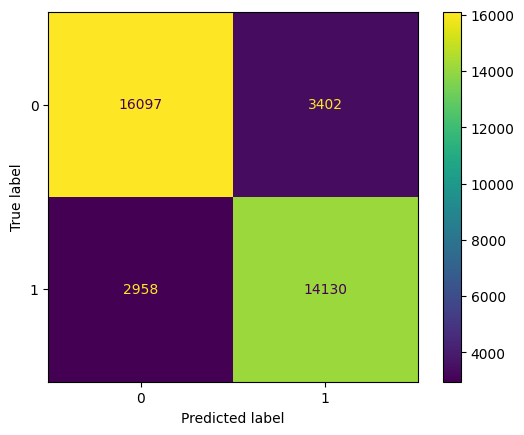

In [331]:
cm = confusion_matrix(y_test, predictions)
ConfusionMatrixDisplay(cm).plot()

# XGBoost

In [332]:
from xgboost import XGBClassifier

xg_model = XGBClassifier(n_estimators = 101, max_depth = 8, learning_rate = 0.05, eval_metric = 'logloss', random_state = 304)
# xg_model = XGBClassifier(n_estimators = 300, max_depth = 6, learning_rate = 0.1, eval_metric = 'logloss', random_state = 856)
xg_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


In [333]:
xg_predictions = xg_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, xg_predictions))

Accuracy: 0.8369092847186159


In [334]:
xg_prob = xg_model.predict_proba(X_test)[:, 1]

In [335]:
xg_auc_score = roc_auc_score(y_true = y_test, y_score = xg_prob)
print("Auc Score:", xg_auc_score)

xg_log_loss = log_loss(y_test, xg_prob)
print("Log Loss Score:", xg_log_loss)

xg_brier_score = brier_score_loss(y_test, xg_prob)
print("Brier Score:", xg_brier_score)

Auc Score: 0.923190597032922
Log Loss Score: 0.34805092769486756
Brier Score: 0.11253380496668858


# Calibration Plots

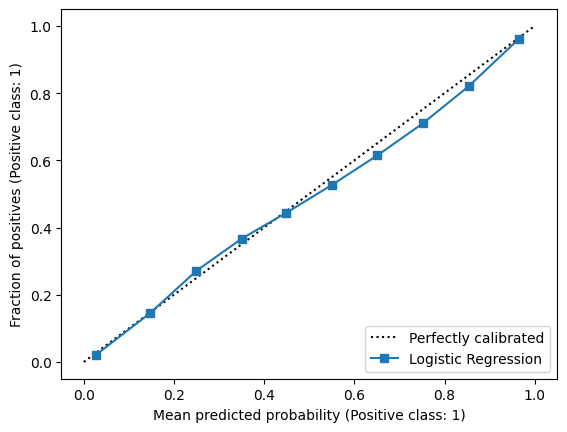

In [336]:
from sklearn.calibration import CalibrationDisplay

CalibrationDisplay.from_predictions(y_test, y_prob, n_bins = 10, name = "Logistic Regression")

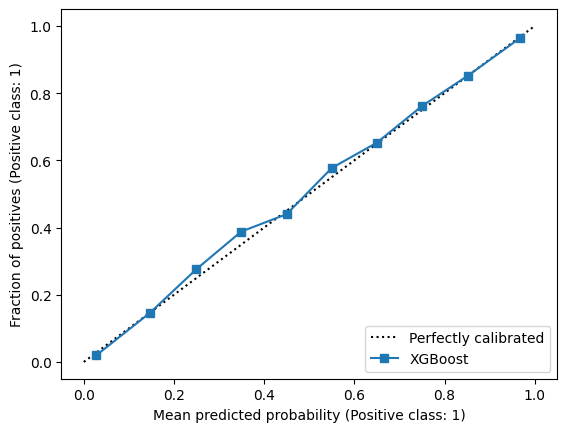

In [337]:
CalibrationDisplay.from_predictions(y_test, xg_prob, n_bins = 10, name = "XGBoost")

# Calibrated XGBoost

In [338]:
from sklearn.calibration import CalibratedClassifierCV

calibrated_xg = CalibratedClassifierCV(xg_model, method='isotonic', cv='prefit')
calibrated_xg.fit(X_test, y_test)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


,estimator,"XGBClassifier...ree=None, ...)"
,method,'isotonic'
,cv,'prefit'
,n_jobs,None
,ensemble,'auto'
,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None


In [339]:
xg_prob_calib = calibrated_xg.predict_proba(X_test)[:, 1]

xg_auc_score_calib = roc_auc_score(y_true = y_test, y_score = xg_prob_calib)
print("Auc Score:", xg_auc_score_calib)

xg_log_loss_calib = log_loss(y_test, xg_prob_calib)
print("Log Loss Score:", xg_log_loss_calib)

xg_brier_score_calib = brier_score_loss(y_test, xg_prob_calib)
print("Brier Score:", xg_brier_score_calib)

Auc Score: 0.9235856703517688
Log Loss Score: 0.34494262377884466
Brier Score: 0.11192145708617912


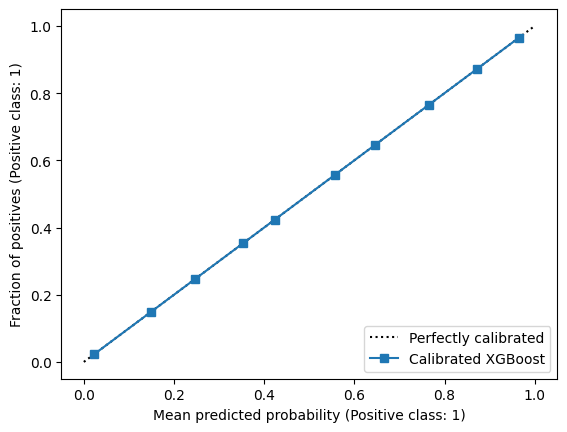

In [340]:
CalibrationDisplay.from_predictions(y_test, xg_prob_calib, n_bins = 10, name = "Calibrated XGBoost")

In [341]:
import shap

In [342]:
explainer = shap.TreeExplainer(xg_model)

In [343]:
shap_values = explainer.shap_values(X_test)

In [344]:
pd.DataFrame(shap_values)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,0.066187,-0.032678,0.022104,0.086884,0.060751,0.231797,-0.434094,-0.377527,-0.381447,-0.030746,-1.009763,0.412503,-0.014873,-0.032604
1,0.001976,-0.032548,0.060350,0.012210,-0.042955,0.079876,-0.430773,-0.457250,-0.337322,0.000809,-0.812486,0.077169,-0.010238,-0.139632
2,-0.009649,-0.018570,0.108868,0.029778,-0.037483,0.055104,-0.514900,-0.617806,-0.324378,0.018338,0.096286,0.043364,0.002541,-0.195662
3,-0.029944,0.009379,0.116801,0.144597,-0.024869,0.002103,-0.189644,-0.655829,-0.828174,0.012655,1.536471,0.001460,0.043650,-0.026383
4,-0.019335,-0.041713,0.097445,0.252667,-0.023037,-0.105068,-0.209554,-0.450152,-0.631665,0.008002,0.943778,0.012858,0.017706,-0.029579
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36582,-0.000034,-0.037196,0.031911,-0.048402,-0.024286,-0.276028,-0.088298,-0.390856,-0.303040,-0.039840,-4.199193,-0.074629,-0.024711,0.040591
36583,0.010182,-0.035310,0.033869,-0.044472,-0.010074,-0.383077,-0.083075,-0.380362,-0.291283,-0.037955,-4.132560,-0.074577,-0.020391,-0.001966
36584,0.012018,-0.036086,0.023114,-0.045123,0.000438,-0.603772,-0.083202,-0.409968,-0.256725,-0.032841,-3.879250,-0.071608,-0.015882,-0.088505
36585,0.012114,-0.035425,0.027302,-0.034016,0.011508,-0.811797,-0.089666,-0.389141,-0.247540,-0.033069,-3.741494,-0.094806,-0.014460,-0.156650


In [345]:
print(features)

['over', 'venue', 'batting_team', 'bowling_team', 'cumul_runs', 'cumul_wickets', 'target', 'required_runs', 'rrr', 'crr', 'crr_rrr_difference', 'wickets_x_balls', 'runs_in_last_3_overs', 'wickets_in_last_3_overs']


SHAP analysis reveals remaining_balls and remaining_wickets contribute zero marginal information — their predictive signal is fully captured by the interaction term wickets_x_balls. Removing them simplifies the model without any loss of predictive power.

In [346]:
shap_importance = pd.DataFrame({'feature': features, 'mean_abs_shap': np.abs(shap_values).mean(axis=0)}).sort_values('mean_abs_shap', ascending=False)
shap_importance

,feature,mean_abs_shap
10,crr_rrr_difference,1.477082
7,required_runs,0.475654
5,cumul_wickets,0.373637
8,rrr,0.362817
6,target,0.185306
11,wickets_x_balls,0.129647
1,venue,0.109777
13,wickets_in_last_3_overs,0.100056
3,bowling_team,0.071078
4,cumul_runs,0.059750


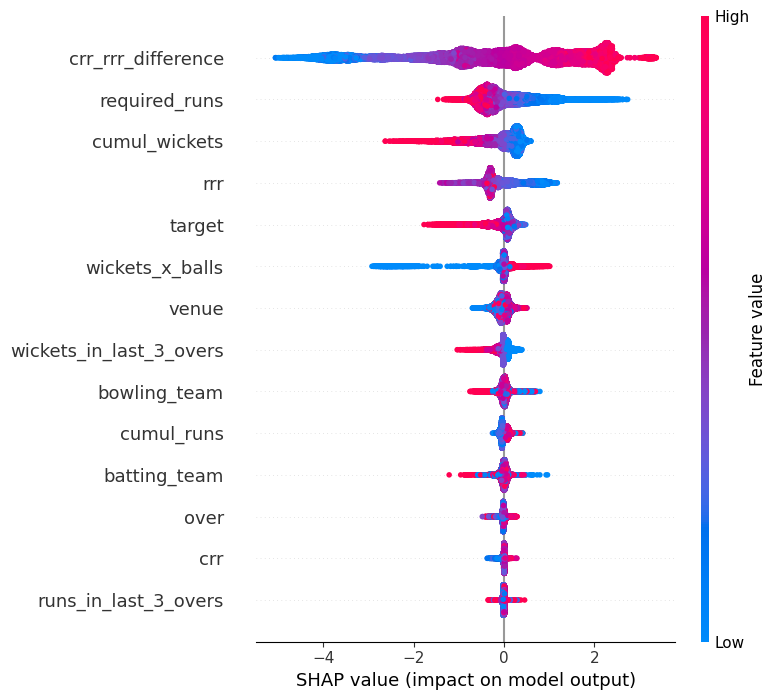

In [347]:
shap.summary_plot(shap_values, X_test, feature_names=features)

In [348]:
df_over[(df_over['competition'].str.contains('World Cup', case=False, na=False)) & (df_over["season"] == 2024) & (df_over["batting_team"] == "South Africa") & (df_over["bowling_team"] == "India")][['match_id', 'date', 'competition', 'batting_team', 'bowling_team']].drop_duplicates('match_id')

,match_id,date,competition,batting_team,bowling_team
90729,1415755,2024-06-29,ICC Men's T20 World Cup,South Africa,India


In [349]:
india_sa = df_model[df_over["match_id"] == "1415755"][features]
india_sa

/var/folders/n_/hd4whr8972b54sv4t6_db9d80000gn/T/ipykernel_40480/2552907880.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  india_sa = df_model[df_over["match_id"] == "1415755"][features]


,over,venue,batting_team,bowling_team,cumul_runs,cumul_wickets,target,required_runs,rrr,crr,crr_rrr_difference,wickets_x_balls,runs_in_last_3_overs,wickets_in_last_3_overs
90729,0,199,193,95,6,0,177,171,9.000000,6.000000,-3.000000,1140,6,0
90730,1,199,193,95,11,1,177,166,9.222222,5.500000,-3.722222,972,11,1
90731,2,199,193,95,14,2,177,163,9.588235,4.666667,-4.921569,816,14,2
90732,3,199,193,95,22,2,177,155,9.687500,5.500000,-4.187500,768,16,2
90733,4,199,193,95,32,2,177,145,9.666667,6.400000,-3.266667,720,21,1
90734,5,199,193,95,42,2,177,135,9.642857,7.000000,-2.642857,672,28,0
90735,6,199,193,95,49,2,177,128,9.846154,7.000000,-2.846154,624,27,0
90736,7,199,193,95,62,2,177,115,9.583333,7.750000,-1.833333,576,30,0
90737,8,199,193,95,71,3,177,106,9.636364,7.888889,-1.747475,462,29,1
90738,9,199,193,95,81,3,177,96,9.600000,8.100000,-1.500000,420,32,1


In [350]:
india_sa_prob = calibrated_xg.predict_proba(india_sa)[:, 1]

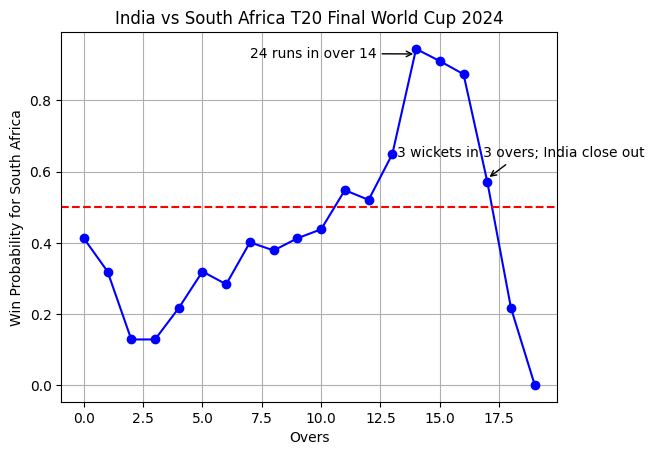

In [351]:
import matplotlib.pyplot as plt

plt.plot(india_sa["over"], india_sa_prob, color = 'blue', marker = 'o')
plt.axhline(y = 0.5, color = 'red', linestyle = '--', label = '50% mark')
plt.annotate('24 runs in over 14', xy = (14, 0.93), xytext = (7, 0.92), arrowprops = dict(arrowstyle='->'))
plt.annotate('3 wickets in 3 overs; India close out', xy = (17, 0.58), xytext = (13.2, 0.64), arrowprops = dict(arrowstyle='->'))
plt.title("India vs South Africa T20 Final World Cup 2024")
plt.xlabel("Overs")
plt.ylabel("Win Probability for South Africa")
plt.grid(True)
plt.show()

In [352]:
df_over[(df_over['competition'].str.contains('Indian Premier League', case=False, na=False)) & (df_over["season"] == 2019) & (df_over["batting_team"] == "Chennai Super Kings") & (df_over["bowling_team"] == "Mumbai Indians")][['match_id', 'date', 'competition', 'batting_team', 'bowling_team']].drop_duplicates('match_id')

,match_id,date,competition,batting_team,bowling_team
22508,1175370,2019-04-03,Indian Premier League,Chennai Super Kings,Mumbai Indians
23292,1178419,2019-04-26,Indian Premier League,Chennai Super Kings,Mumbai Indians
23645,1181768,2019-05-12,Indian Premier League,Chennai Super Kings,Mumbai Indians


In [353]:
mi_csk = df_model[df_over["match_id"] == "1181768"][features]
mi_csk

/var/folders/n_/hd4whr8972b54sv4t6_db9d80000gn/T/ipykernel_40480/1279676696.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  mi_csk = df_model[df_over["match_id"] == "1181768"][features]


,over,venue,batting_team,bowling_team,cumul_runs,cumul_wickets,target,required_runs,rrr,crr,crr_rrr_difference,wickets_x_balls,runs_in_last_3_overs,wickets_in_last_3_overs
23645,0,324,31,144,7,0,150,143,7.526316,7.000000,-0.526316,1140,7,0
23646,1,324,31,144,12,0,150,138,7.666667,6.000000,-1.666667,1080,12,0
23647,2,324,31,144,19,0,150,131,7.705882,6.333333,-1.372549,1020,19,0
23648,3,324,31,144,33,1,150,117,7.312500,8.250000,0.937500,864,26,1
23649,4,324,31,144,38,1,150,112,7.466667,7.600000,0.133333,810,26,1
23650,5,324,31,144,53,1,150,97,6.928571,8.833333,1.904762,756,34,1
23651,6,324,31,144,57,1,150,93,7.153846,8.142857,0.989011,702,24,0
23652,7,324,31,144,60,1,150,90,7.500000,7.500000,0.000000,648,22,0
23653,8,324,31,144,70,1,150,80,7.272727,7.777778,0.505051,594,17,0
23654,9,324,31,144,72,2,150,78,7.800000,7.200000,-0.600000,480,15,1


In [354]:
mi_csk_prob = calibrated_xg.predict_proba(mi_csk)[:, 1]

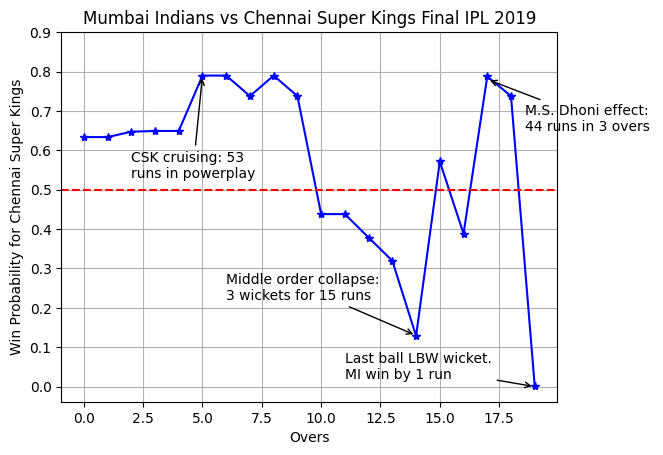

In [355]:
plt.plot(mi_csk["over"], mi_csk_prob, color = 'blue', marker = '*')
plt.axhline(y = 0.5, color = 'red', linestyle = '--', label = '50% mark')

plt.annotate('CSK cruising: 53 \nruns in powerplay', xy = (5, 0.79), xytext = (2, 0.53), arrowprops = dict(arrowstyle='->'))
plt.annotate('Middle order collapse: \n3 wickets for 15 runs', xy = (14, 0.13), xytext = (6, 0.22), arrowprops = dict(arrowstyle='->'))
plt.annotate('Last ball LBW wicket.\nMI win by 1 run', xy = (19, 0), xytext = (11, 0.02), arrowprops = dict(arrowstyle='->'))
plt.annotate('M.S. Dhoni effect: \n44 runs in 3 overs', xy = (17, 0.78), xytext = (18.6, 0.65), arrowprops = dict(arrowstyle='->'))

plt.title("Mumbai Indians vs Chennai Super Kings Final IPL 2019")
plt.xlabel("Overs")
plt.ylabel("Win Probability for Chennai Super Kings")
plt.yticks([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])
plt.grid(True)
plt.show()

In [356]:
import joblib
joblib.dump(calibrated_xg, 'model.pkl')

['model.pkl']

In [357]:
median_runs_last3 = X_train['runs_in_last_3_overs'].median()
median_wickets_last3 = X_train['wickets_in_last_3_overs'].median()

In [358]:
joblib.dump({
    'median_runs_last3': median_runs_last3,
    'median_wickets_last3': median_wickets_last3
}, 'medians.pkl')

['medians.pkl']

In [359]:
joblib.dump(encoders, 'encoders.pkl')

['encoders.pkl']